In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import src

mpl.rc("text", usetex=True)
mpl.rc("font", family="serif")

In [ ]:
enoe = pd.read_parquet("outputs/enoe_harmonized.parquet")
od = pd.read_parquet("outputs/od_sector_imputed.parquet")
print(f"ENOE workers: {len(enoe):,}")
print(f"OD workers: {len(od):,}")

ENOE workers: 6,793
OD workers: 26,913


## Informality probability model

The ENOE survey observes whether each worker has a formal or informal job, whereas the OD survey does not contain this label. The objective of this stage is therefore to learn the relationship between informality and the harmonized worker characteristics available in both surveys. For an ENOE worker, the model estimates $P(I=1\mid X,S)$, where $I=1$ denotes informal employment, $X$ contains the common sociodemographic and labor attributes, and $S$ denotes economic sector. Sector is observed in ENOE but is uncertain for part of the OD population. Rather than replacing this uncertainty with a single hard sector label, the OD informality probability is obtained by marginalizing over the four possible sectors,

$$P(I_i=1\mid X_i)=\sum_s P(I_i=1\mid X_i,S_i=s)\,P(S_i=s\mid X_i).$$

For workers whose sector was originally observed, $P(S_i=s\mid X_i)$ is one-hot and the expression reduces to the usual conditional prediction. For workers whose sector was imputed, the full sector probability vector is retained. Models are trained using ENOE survey weights and selected primarily through weighted log loss so that predicted probabilities, rather than only hard formal/informal classifications, are the main output.

In [ ]:
maximum_sector_probability_error = src.validate_od_sector_probabilities(od)
print(f"Maximum sector probability-sum error: {maximum_sector_probability_error:.3e}")

Maximum sector probability-sum error: 2.220e-16


## Training geography

The informality model is trained using ENOE workers from municipalities represented in both ENOE and OD. This preserves the same geographic comparison used in the previous benchmark analysis.

In [ ]:
enoe_informality, geography_summary = src.select_common_informality_population(enoe, od)
print(geography_summary)
print(f"ENOE workers used for informality analysis: {len(enoe_informality):,}")

                municipio   enoe     od  common
0                el_salto   True   True    True
1             guadalajara   True   True    True
2  ixtlahuacan_membrillos   True   True    True
3             juanacatlan  False   True   False
4                    tala   True  False   False
5              tlajomulco   True   True    True
6             tlaquepaque   True   True    True
7                  tonala   True   True    True
8                 zapopan   True   True    True
9             zapotlanejo  False   True   False
ENOE workers used for informality analysis: 5,105


In [ ]:
informality_benchmark = src.calculate_enoe_informality_benchmark(enoe_informality)
print(informality_benchmark.round(4))

   sample_workers  weighted_population  weighted_informal_population  \
0            5105            2427532.0                      944728.0   

   unweighted_informality_rate  weighted_informality_rate  
0                       0.3929                     0.3892  


## Predictor missingness

The common ENOE–OD predictors are inspected before training. Education is evaluated explicitly because missing education is considerably more frequent in OD than in ENOE.

In [ ]:
predictor_columns = ["genero", "ocupacion", "edad_num", "escolaridad", "municipio", "estado_civil", "parentesco", "tamano_viv_cat"]
predictor_missingness = src.compare_informality_feature_missingness(enoe_informality, od, predictor_columns)
print(predictor_missingness.round(4))

## Common ENOE train-test split

A held-out ENOE test sample is reserved before model tuning. Workers belonging to the same household are kept within the same partition.

In [6]:
enoe_informality_train, enoe_informality_test = src.split_enoe_informality_data(enoe_informality, n_splits=5, test_fold=0, random_state=42)
print(f"ENOE workers available for training: {len(enoe_informality_train):,}")
print(f"ENOE workers reserved for testing: {len(enoe_informality_test):,}")

ENOE workers available for training: 4,078
ENOE workers reserved for testing: 1,027


## Model A: predictors with education

In [7]:
with_education_features = src.INFORMALITY_FEATURES
X_with_education, y_with_education, weights_with_education, groups_with_education, training_with_education = src.prepare_enoe_informality_training_data(enoe_informality_train, features=with_education_features)
print(f"Workers used for training: {len(training_with_education):,}")
print(f"Households used for training: {groups_with_education.nunique():,}")

Workers used for training: 4,078
Households used for training: 2,188


In [8]:
# Tune
with_education_summary, with_education_models = src.tune_informality_models(X_with_education, y_with_education, weights_with_education, groups_with_education, features=with_education_features, cv_splits=5, random_state=42)
print(with_education_summary)

Tuning LogisticRegression: 3 parameter combinations
Tuning RandomForest: 12 parameter combinations
Tuning GradientBoosting: 8 parameter combinations
                model  weighted_log_loss  weighted_log_loss_std  \
0        RandomForest           0.506499               0.032967   
1    GradientBoosting           0.508257               0.033497   
2  LogisticRegression           0.541052               0.026052   

   weighted_brier_score  weighted_balanced_accuracy  weighted_accuracy  \
0              0.166189                    0.740989           0.765596   
1              0.167515                    0.736722           0.761920   
2              0.181597                    0.697878           0.726717   

   weighted_f1  weighted_roc_auc  \
0     0.679054          0.818319   
1     0.673221          0.815493   
2     0.614706          0.785214   

                                         best_params  
0  {'classifier__max_features': 0.7, 'classifier_...  
1  {'classifier__l2_regulariza

In [9]:
# Best model
with_education_best_name, with_education_best_model = src.get_best_informality_model(with_education_summary, with_education_models)
print(f"Best model with education: {with_education_best_name}")
print(with_education_summary.loc[with_education_summary["model"] == with_education_best_name, "best_params"].iloc[0])

Best model with education: RandomForest
{'classifier__max_features': 0.7, 'classifier__max_leaf_nodes': 50, 'classifier__min_samples_leaf': 5}


In [10]:
# Held-out evaluation
with_education_metrics, with_education_confusion, with_education_calibration = src.evaluate_informality_model(with_education_best_model, enoe_informality_test, features=with_education_features)
print(with_education_metrics.round(4))
print(with_education_confusion.round(2))
print(with_education_calibration.round(4))

   accuracy  balanced_accuracy      f1  weighted_accuracy  \
0    0.7556             0.7269  0.6499             0.7572   

   weighted_balanced_accuracy  weighted_f1  weighted_roc_auc  \
0                      0.7224        0.637            0.8019   

   weighted_log_loss  weighted_brier_score  observed_informality_rate  \
0             0.5116                0.1691                     0.3523   

   predicted_informality_rate  calibration_gap_pp  
0                       0.387               3.465  
            formal  informal
formal    263885.0   50172.0
informal   67558.0  103286.0
             bin  sample_workers  weighted_population  weighted_informal  \
0  (-0.001, 0.1]              56              26082.0             1238.0   
1     (0.1, 0.2]             276             138458.0            15716.0   
2     (0.2, 0.3]             152              76214.0            20317.0   
3     (0.3, 0.4]             137              61270.0            20100.0   
4     (0.4, 0.5]              

## Model B: predictors without education

A second specification excludes education so that workers with unavailable education in OD do not depend on a category that is rarely observed as missing in ENOE.

In [11]:
without_education_features = src.INFORMALITY_ROBUST_FEATURES
X_without_education, y_without_education, weights_without_education, groups_without_education, training_without_education = src.prepare_enoe_informality_training_data(enoe_informality_train, features=without_education_features)
print(f"Workers used for training: {len(training_without_education):,}")
print(f"Households used for training: {groups_without_education.nunique():,}")

Workers used for training: 4,078
Households used for training: 2,188


In [12]:
# Tune
without_education_summary, without_education_models = src.tune_informality_models(X_without_education, y_without_education, weights_without_education, groups_without_education, features=without_education_features, cv_splits=5, random_state=42)
print(without_education_summary)

Tuning LogisticRegression: 3 parameter combinations
Tuning RandomForest: 12 parameter combinations
Tuning GradientBoosting: 8 parameter combinations
                model  weighted_log_loss  weighted_log_loss_std  \
0        RandomForest           0.544722               0.041484   
1    GradientBoosting           0.548662               0.040626   
2  LogisticRegression           0.589692               0.036941   

   weighted_brier_score  weighted_balanced_accuracy  weighted_accuracy  \
0              0.182679                    0.701007           0.735668   
1              0.183786                    0.697571           0.731602   
2              0.201519                    0.663852           0.707673   

   weighted_f1  weighted_roc_auc  \
0     0.612251          0.775926   
1     0.609344          0.772213   
2     0.546664          0.722685   

                                         best_params  
0  {'classifier__max_features': 0.7, 'classifier_...  
1  {'classifier__l2_regulariza

In [13]:
# Best model 
without_education_best_name, without_education_best_model = src.get_best_informality_model(without_education_summary, without_education_models)
print(f"Best model without education: {without_education_best_name}")
print(without_education_summary.loc[without_education_summary["model"] == without_education_best_name, "best_params"].iloc[0])

Best model without education: RandomForest
{'classifier__max_features': 0.7, 'classifier__max_leaf_nodes': 50, 'classifier__min_samples_leaf': 5}


In [14]:
# Held-out evaluation
without_education_metrics, without_education_confusion, without_education_calibration = src.evaluate_informality_model(without_education_best_model, enoe_informality_test, features=without_education_features)
print(without_education_metrics.round(4))
print(without_education_confusion.round(2))
print(without_education_calibration.round(4))

   accuracy  balanced_accuracy      f1  weighted_accuracy  \
0    0.7429             0.7006  0.6071             0.7461   

   weighted_balanced_accuracy  weighted_f1  weighted_roc_auc  \
0                      0.6986       0.5988            0.7711   

   weighted_log_loss  weighted_brier_score  observed_informality_rate  \
0             0.5325                0.1773                     0.3523   

   predicted_informality_rate  calibration_gap_pp  
0                      0.3931              4.0814  
            formal  informal
formal    269949.0   44108.0
informal   78994.0   91850.0
             bin  sample_workers  weighted_population  weighted_informal  \
0  (-0.001, 0.1]              27              18687.0              384.0   
1     (0.1, 0.2]             171              87741.0            11263.0   
2     (0.2, 0.3]             274             126254.0            30657.0   
3     (0.3, 0.4]             159              70314.0            15387.0   
4     (0.4, 0.5]             1

## Model comparison

Weighted log loss and Brier score are the primary probability-quality metrics. Classification metrics are retained as secondary diagnostics, while the difference between the observed and predicted weighted informality rates provides a direct calibration check.

In [15]:
model_comparison = pd.concat([with_education_metrics.assign(features="Con escolaridad"), without_education_metrics.assign(features="Sin escolaridad")], ignore_index=True)
print(model_comparison.round(4))

   accuracy  balanced_accuracy      f1  weighted_accuracy  \
0    0.7556             0.7269  0.6499             0.7572   
1    0.7429             0.7006  0.6071             0.7461   

   weighted_balanced_accuracy  weighted_f1  weighted_roc_auc  \
0                      0.7224       0.6370            0.8019   
1                      0.6986       0.5988            0.7711   

   weighted_log_loss  weighted_brier_score  observed_informality_rate  \
0             0.5116                0.1691                     0.3523   
1             0.5325                0.1773                     0.3523   

   predicted_informality_rate  calibration_gap_pp         features  
0                      0.3870              3.4650  Con escolaridad  
1                      0.3931              4.0814  Sin escolaridad  


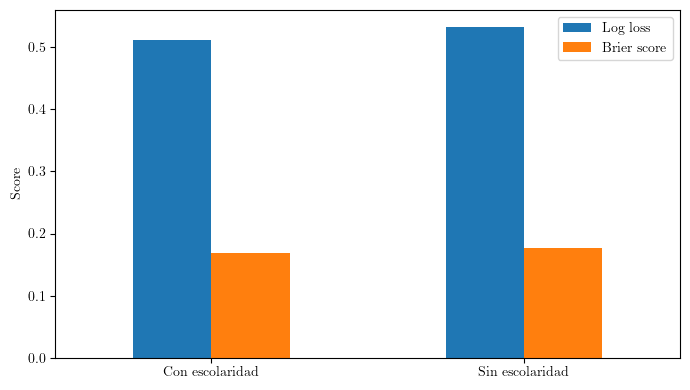

In [16]:
plot_data = model_comparison.set_index("features")[["weighted_log_loss", "weighted_brier_score"]]
ax = plot_data.plot(kind="bar", figsize=(7, 4))
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.tick_params(axis="x", rotation=0)
ax.legend(["Log loss", "Brier score"])
plt.tight_layout()
plt.show()

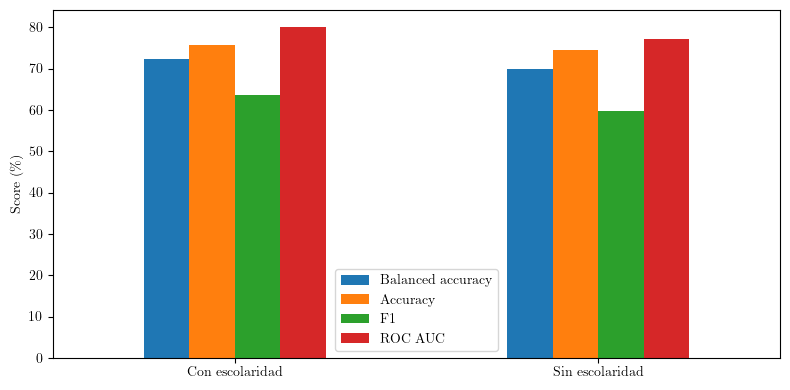

In [17]:
plot_data = model_comparison.set_index("features")[["weighted_balanced_accuracy", "weighted_accuracy", "weighted_f1", "weighted_roc_auc"]] * 100
ax = plot_data.plot(kind="bar", figsize=(8, 4))
ax.set_xlabel("")
ax.set_ylabel("Score (\\%)")
ax.tick_params(axis="x", rotation=0)
ax.legend(["Balanced accuracy", "Accuracy", "F1", "ROC AUC"])
plt.tight_layout()
plt.show()

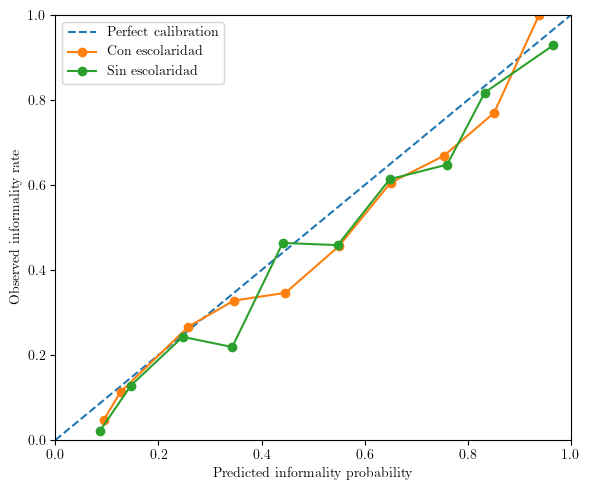

In [18]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
ax.plot(with_education_calibration["predicted_probability"], with_education_calibration["observed_rate"], marker="o", label="Con escolaridad")
ax.plot(without_education_calibration["predicted_probability"], without_education_calibration["observed_rate"], marker="o", label="Sin escolaridad")
ax.set_xlabel("Predicted informality probability")
ax.set_ylabel("Observed informality rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

In [37]:
print(f"Best model test accuracy: {with_education_metrics.loc[0, 'accuracy']:.4f}")
print(f"Best model test balanced accuracy: {with_education_metrics.loc[0, 'balanced_accuracy']:.4f}")
print(f"Best model weighted test accuracy: {with_education_metrics.loc[0, 'weighted_accuracy']:.4f}")
print(f"Best model weighted test balanced accuracy: {with_education_metrics.loc[0, 'weighted_balanced_accuracy']:.4f}")

Best model test accuracy: 0.7556
Best model test balanced accuracy: 0.7269
Best model weighted test accuracy: 0.7572
Best model weighted test balanced accuracy: 0.7224


## Final hybrid informality model

The final specification retains education whenever it is observed and uses the model without education when this predictor is unavailable. Both models are refitted using the complete ENOE training population. Sector uncertainty from the previous stage is propagated by averaging the conditional informality probabilities over the four sector probabilities.

In [19]:
final_with_education_model, final_with_education_training = src.refit_informality_model(with_education_best_model, enoe_informality, features=with_education_features)
final_without_education_model, final_without_education_training = src.refit_informality_model(without_education_best_model, enoe_informality, features=without_education_features)
print(f"Workers used for final ENOE training: {len(final_with_education_training):,}")

Workers used for final ENOE training: 5,105


In [20]:
od_informality = src.predict_od_informality(final_with_education_model, final_without_education_model, od, with_education_features=with_education_features, without_education_features=without_education_features)

In [21]:
informality_model_usage = src.calculate_informality_model_usage(od_informality)
print(informality_model_usage.round(4))

  informality_model_used  sample_workers  weighted_population  sample_share  \
0         with_education           21718              1913445         0.807   
1      without_education            5195               358933         0.193   

   weighted_share  
0           0.842  
1           0.158  


In [23]:
od_informality_summary = src.calculate_od_informality_summary(od_informality)
print(od_informality_summary.round(4))

   sample_workers  weighted_population  expected_informal_population  \
0           26913              2272378                   765129.2491   

   expected_formal_population  expected_informality_rate  \
0                1.507249e+06                     0.3367   

   hard_informality_rate  hard_sector_expected_rate  
0                 0.2135                     0.3411  


In [24]:
informality_by_sector = src.calculate_informality_by_sector(od_informality)
print(informality_by_sector.round(4))

                      sector  weighted_population  \
0                   comercio          701940.1247   
1  gobierno_otro_agricultura          122619.5777   
2   manufactura_construccion          617885.8211   
3       servicios_transporte          829932.4765   

   expected_informal_population  expected_formal_population  \
0                   289543.3518                 412396.7728   
1                    16775.3837                 105844.1941   
2                   140428.8358                 477456.9853   
3                   318381.6778                 511550.7987   

   expected_informality_rate  
0                     0.4125  
1                     0.1368  
2                     0.2273  
3                     0.3836  


## Comparison of ENOE Results with the Model

In [30]:
comparison_enoe_od = pd.DataFrame({
    "estimate": [
        "ENOE weighted benchmark",
        "OD hard prediction",
        "OD expected probability"
    ],
    "informality_rate": [
        informality_benchmark.loc[0, "weighted_informality_rate"],
        od_informality_summary.loc[0, "hard_informality_rate"],
        od_informality_summary.loc[0, "expected_informality_rate"]
    ]
})

comparison_enoe_od["difference_from_enoe_pp"] = (comparison_enoe_od["informality_rate"] - informality_benchmark.loc[0, "weighted_informality_rate"]) * 100
print(comparison_enoe_od.round(4))

                  estimate  informality_rate  difference_from_enoe_pp
0  ENOE weighted benchmark            0.3892                   0.0000
1       OD hard prediction            0.2135                 -17.5700
2  OD expected probability            0.3367                  -5.2464


In [35]:
# Fraction of informal employment distributed by sector
sector_labels = {
    "comercio": "Comercio",
    "gobierno_otro_agricultura": "Gobierno, otro y agricultura",
    "manufactura_construccion": "Manufactura y construcción",
    "servicios_transporte": "Servicios y transporte"
}

sector_order = list(sector_labels.keys())

# OD hard
od_hard_informal = od_informality[od_informality["informal_predicted"] == 1].copy()
od_hard_by_sector = od_hard_informal.groupby("sector_final")["expansion_factor"].sum().reindex(sector_order, fill_value=0)
od_hard_by_sector = od_hard_by_sector / od_hard_by_sector.sum()

# OD expected
od_expected_by_sector = pd.Series({
    sector: (od_informality["expansion_factor"] * od_informality[f"prob_informal_sector_{sector}"]).sum()
    for sector in sector_order
})
od_expected_by_sector = od_expected_by_sector / od_expected_by_sector.sum()

# ENOE
enoe_informal = enoe_informality[enoe_informality["informal"] == 1].copy()
enoe_by_sector = enoe_informal.groupby("sector")["survey_weight"].sum().reindex(sector_order, fill_value=0)
enoe_by_sector = enoe_by_sector / enoe_by_sector.sum()

informal_distribution_by_sector = pd.DataFrame({
    "OD hard": od_hard_by_sector * 100,
    "OD expected": od_expected_by_sector * 100,
    "ENOE": enoe_by_sector * 100
})

informal_distribution_by_sector.index = informal_distribution_by_sector.index.map(sector_labels)
informal_distribution_by_sector.index.name = "sector"

print(informal_distribution_by_sector.round(2))

                              OD hard  OD expected   ENOE
sector                                                   
Comercio                         46.7        37.84  28.22
Gobierno, otro y agricultura     0.79         2.19   2.54
Manufactura y construcción       9.88        18.35  23.73
Servicios y transporte          42.63        41.61  45.51


In [36]:
# Fraction of informal employment within each sector

# OD hard
od_hard_sector_population = od_informality.groupby("sector_final")["expansion_factor"].sum().reindex(sector_order, fill_value=0)

od_hard_informal_population = od_informality[od_informality["informal_predicted"] == 1].groupby("sector_final")["expansion_factor"].sum().reindex(sector_order, fill_value=0)

od_hard_within_sector = od_hard_informal_population / od_hard_sector_population

# OD expected
od_expected_within_sector = pd.Series({
    sector: (
        (od_informality["expansion_factor"] * od_informality[f"prob_informal_sector_{sector}"]).sum()
        /
        (od_informality["expansion_factor"] * od_informality[f"prob_sector_{sector}"]).sum()
    )
    for sector in sector_order
})

# ENOE
enoe_sector_population = enoe_informality.groupby("sector")["survey_weight"].sum().reindex(sector_order, fill_value=0)

enoe_informal_population = enoe_informality[enoe_informality["informal"] == 1].groupby("sector")["survey_weight"].sum().reindex(sector_order, fill_value=0)

enoe_within_sector = enoe_informal_population / enoe_sector_population

informality_within_sector = pd.DataFrame({
    "OD hard": od_hard_within_sector * 100,
    "OD expected": od_expected_within_sector * 100,
    "ENOE": enoe_within_sector * 100
})

informality_within_sector.index = informality_within_sector.index.map(sector_labels)
informality_within_sector.index.name = "sector"

print(informality_within_sector.round(2))

                              OD hard  OD expected   ENOE
sector                                                   
Comercio                        35.91        41.25  47.59
Gobierno, otro y agricultura     5.93        13.68  17.76
Manufactura y construcción       7.82        22.73  30.02
Servicios y transporte          21.45        38.36  43.63


## Export and final validation

In [31]:
od_informality["formalidad_predicha"] = od_informality["informal_predicted"].map({0: "formal", 1: "informal"}).astype("string")

assert len(od_informality) == len(od)
assert od_informality["prob_informal"].notna().all()
assert od_informality["prob_formal"].notna().all()
assert od_informality["informal_predicted"].notna().all()
assert od_informality["prob_informal"].between(0, 1).all()
assert od_informality["prob_formal"].between(0, 1).all()
assert ((od_informality["prob_informal"] + od_informality["prob_formal"] - 1).abs() < 1e-8).all()
assert od_informality["expected_informal_population"].notna().all()
assert od_informality["expected_formal_population"].notna().all()

print("Final informality validation passed.")

Final informality validation passed.


In [32]:
total_population = od_informality["expansion_factor"].sum()
informal_population = od_informality["expected_informal_population"].sum()
formal_population = od_informality["expected_formal_population"].sum()

print(f"Total weighted workers: {total_population:,.0f}")
print(f"Expected informal workers: {informal_population:,.0f}")
print(f"Expected formal workers: {formal_population:,.0f}")
print(f"Population difference: {total_population - informal_population - formal_population:.6f}")

Total weighted workers: 2,272,378
Expected informal workers: 765,129
Expected formal workers: 1,507,249
Population difference: 0.000000


In [33]:
output_directory = Path("outputs")
output_directory.mkdir(exist_ok=True)

output_path = output_directory / "od_informality_imputed.parquet"
od_informality.to_parquet(output_path, index=False)

In [34]:
from joblib import dump

models_directory = Path("outputs/models")
models_directory.mkdir(parents=True, exist_ok=True)

informality_model_bundle = {
    "model_with_education": final_with_education_model,
    "model_without_education": final_without_education_model,
    "features_with_education": with_education_features,
    "features_without_education": without_education_features,
    "sector_classes": src.informality_model.SECTOR_CLASSES
}

model_path = models_directory / "informality_hybrid_model.joblib"
dump(informality_model_bundle, model_path)

print(f"Saved: {model_path}")

Saved: outputs/models/informality_hybrid_model.joblib
